**Dependency note:** this notebook needs kernel state from **`06_Incremental_Spatial_Expansion`**. Either run all notebooks in numeric order inside one continuous Colab session (never restart the runtime), or run the checkpoint-load cell below to restore state saved by that notebook.

In [ ]:
# ── CHECKPOINT: restore kernel state from the previous notebook ──
# This notebook depends on variables created in 06.
# Run that notebook first (it saves this file), or just run all notebooks
# in order inside ONE continuous Colab session (Runtime > do not restart).
import dill
dill.load_session("checkpoints/06_state.pkl")
print("Restored checkpoint: checkpoints/06_state.pkl")

Axon Whorl and other new phenomenon investigation

In [ ]:
# ============================================================
# AXON WHORL DETECTION
# ============================================================
# Without skeleton data we detect whorls through 4 connectivity
# signatures that whorls produce in the hypergraph:
#
# SIGNATURE 1 — Spatial compactness anomaly
#   A whorl covers tiny spatial area but high hyperedge count
#   Score: hyperdegree / spatial_spread
#   (normal axons: low score; whorls: very high score)
#
# SIGNATURE 2 — Local hyperedge clustering
#   Whorls create dense clusters of hyperedges in small volumes
#   Score: number of hyperedges within 5μm radius
#   (normal: sparse; whorl: dense cluster)
#
# SIGNATURE 3 — Re-entrant co-occurrence
#   Whorl axons repeatedly contact the same neurons
#   Score: max co-occurrence weight / mean co-occurrence weight
#   (normal: ~1.0; whorl: high ratio = repeated contact)
#
# SIGNATURE 4 — Pyramidal soma proximity
#   From the image: whorls preferentially occur ON pyramidal somas
#   Score: interneurons with unusually many pyramidal neighbors
#   within very short radius (5μm vs normal 15μm)
# ============================================================

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import scipy.sparse as sp
from scipy.stats import zscore

print("Computing whorl detection signatures...")
print(f"Working on {len(patch)} neurons in cortical patch")

# ── Setup ─────────────────────────────────────────────────────
inter_coords_full = np.array([
    [patch.loc[n]['x'], patch.loc[n]['y'], patch.loc[n]['z']]
    for n in all_nodes
])
pyr_coords_full = patch[patch['celltype']=='PYRAMIDAL'][
    ['x','y','z']].values
pyr_nodes_full  = patch[patch['celltype']=='PYRAMIDAL'].index.tolist()

inter_tree_full = cKDTree(inter_coords_full)
pyr_tree_full   = cKDTree(pyr_coords_full)

# ── SIGNATURE 1: Spatial compactness anomaly ──────────────────
print("\nComputing Signature 1: Spatial compactness...")

WHORL_RADIUS    = 5000    # 5μm — tight whorl radius
NORMAL_RADIUS   = 15000   # 15μm — normal axon radius

sig1_scores = np.zeros(n_nodes)

for i, node in enumerate(all_nodes):
    coord = inter_coords_full[i]

    # Count hyperedges within tight radius (whorl scale)
    tight_neighbors = inter_tree_full.query_ball_point(
        coord, WHORL_RADIUS)
    n_tight = len(tight_neighbors)

    # Count hyperedges within normal radius
    normal_neighbors = inter_tree_full.query_ball_point(
        coord, NORMAL_RADIUS)
    n_normal = len(normal_neighbors)

    # Compactness = fraction of connections at whorl scale
    # High = most connections are spatially compact = whorl-like
    if n_normal > 0:
        sig1_scores[i] = n_tight / n_normal

print(f"  Sig1 range: [{sig1_scores.min():.4f}, "
      f"{sig1_scores.max():.4f}]")
print(f"  Sig1 mean:  {sig1_scores.mean():.4f}")

# ── SIGNATURE 2: Local hyperedge clustering ───────────────────
print("Computing Signature 2: Local hyperedge clustering...")

# For each interneuron, count how many OTHER interneurons
# share hyperedges AND are within whorl radius
# High = dense local hyperedge cluster = whorl territory
sig2_scores = np.zeros(n_nodes)

C_w_arr = C_w.toarray()   # co-occurrence matrix

for i in range(n_nodes):
    # Interneurons within whorl radius
    tight_neighbors = inter_tree_full.query_ball_point(
        inter_coords_full[i], WHORL_RADIUS)
    tight_neighbors = [j for j in tight_neighbors if j != i]

    if not tight_neighbors:
        continue

    # How many of these also co-occur in hyperedges?
    co_occur_tight = sum(
        1 for j in tight_neighbors if C_w_arr[i, j] > 0)

    sig2_scores[i] = co_occur_tight / max(len(tight_neighbors), 1)

print(f"  Sig2 range: [{sig2_scores.min():.4f}, "
      f"{sig2_scores.max():.4f}]")
print(f"  Sig2 mean:  {sig2_scores.mean():.4f}")

# ── SIGNATURE 3: Re-entrant co-occurrence ─────────────────────
print("Computing Signature 3: Re-entrant co-occurrence...")

sig3_scores = np.zeros(n_nodes)

for i in range(n_nodes):
    row = C_w_arr[i, :]
    nonzero = row[row > 0]
    if len(nonzero) < 2:
        continue
    # High max/mean ratio = one partner contacted many more
    # times than others = re-entrant (whorl-like)
    sig3_scores[i] = nonzero.max() / nonzero.mean()

print(f"  Sig3 range: [{sig3_scores.min():.4f}, "
      f"{sig3_scores.max():.4f}]")
print(f"  Sig3 mean:  {sig3_scores.mean():.4f}")

# ── SIGNATURE 4: Pyramidal soma proximity density ─────────────
print("Computing Signature 4: Pyramidal soma proximity...")

SOMA_RADIUS = 8000   # 8μm — on-soma proximity

sig4_scores = np.zeros(n_nodes)

for i, node in enumerate(all_nodes):
    coord = inter_coords_full[i]

    # Count pyramidal somas within very tight radius
    # (whorls are ON the soma from the image)
    soma_nearby = pyr_tree_full.query_ball_point(
        coord, SOMA_RADIUS)
    n_soma_nearby = len(soma_nearby)

    # Normalize by expected density at this location
    normal_nearby = pyr_tree_full.query_ball_point(
        coord, NORMAL_RADIUS)
    n_normal_pyr = len(normal_nearby)

    if n_normal_pyr > 0:
        sig4_scores[i] = n_soma_nearby / n_normal_pyr

print(f"  Sig4 range: [{sig4_scores.min():.4f}, "
      f"{sig4_scores.max():.4f}]")
print(f"  Sig4 mean:  {sig4_scores.mean():.4f}")

# ── Combine signatures into whorl score ───────────────────────
print("\nCombining signatures into whorl detection score...")

# Z-score each signature for equal weighting
sig1_z = zscore(sig1_scores)
sig2_z = zscore(sig2_scores)
sig3_z = zscore(sig3_scores)
sig4_z = zscore(sig4_scores)

# Combined score — equal weights
# Higher = more whorl-like
whorl_score = (sig1_z + sig2_z + sig3_z + sig4_z) / 4.0

# Normalize to [0,1]
whorl_score_norm = (whorl_score - whorl_score.min()) / (
    whorl_score.max() - whorl_score.min())

print(f"\nWhorl detection score:")
print(f"  Mean:   {whorl_score_norm.mean():.4f}")
print(f"  Std:    {whorl_score_norm.std():.4f}")
print(f"  Max:    {whorl_score_norm.max():.4f}")

# ── Classify whorl candidates ─────────────────────────────────
# Threshold: top 5% of scores = whorl candidates
threshold_95 = np.percentile(whorl_score_norm, 95)
threshold_99 = np.percentile(whorl_score_norm, 99)

whorl_candidates_95 = np.where(
    whorl_score_norm >= threshold_95)[0]
whorl_candidates_99 = np.where(
    whorl_score_norm >= threshold_99)[0]

print(f"\nWhorl candidates:")
print(f"  Top 5%  (score>{threshold_95:.3f}): "
      f"{len(whorl_candidates_95)} neurons")
print(f"  Top 1%  (score>{threshold_99:.3f}): "
      f"{len(whorl_candidates_99)} neurons")

# ── Per-layer whorl distribution ──────────────────────────────
print(f"\nWhorl candidate layer distribution (top 5%):")
whorl_layers = layer_labels[whorl_candidates_95]
unique, counts = np.unique(whorl_layers, return_counts=True)
total_by_layer = {l: (layer_labels==l).sum() for l in unique}
for l, c in zip(unique, counts):
    pct = c / total_by_layer[l] * 100
    print(f"  {l:12s}: {c:3d} candidates "
          f"({pct:.1f}% of layer)")

# ── Top 20 whorl candidates ───────────────────────────────────
top20_whorl = np.argsort(whorl_score_norm)[::-1][:20]
print(f"\nTop 20 whorl candidates:")
print(f"  {'Rank':>4} {'Node':>6} {'Layer':>12} "
      f"{'Score':>8} {'Sig1':>8} {'Sig2':>8} "
      f"{'Sig3':>8} {'Sig4':>8}")
print(f"  {'-'*66}")
for rank, ti in enumerate(top20_whorl):
    orig = all_nodes[ti]
    print(f"  {rank+1:>4} {orig:>6} "
          f"{layer_labels[ti]:>12} "
          f"{whorl_score_norm[ti]:>8.4f} "
          f"{sig1_z[ti]:>8.3f} "
          f"{sig2_z[ti]:>8.3f} "
          f"{sig3_z[ti]:>8.3f} "
          f"{sig4_z[ti]:>8.3f}")

# ── Correlation with seizure focus ────────────────────────────
from scipy.stats import spearmanr
seizure_score = cent_pyr * cent_mgopc \
    if 'cent_mgopc' in globals() \
    else tensor_centrality

r_whorl_seizure, p_whorl_seizure = spearmanr(
    whorl_score_norm, seizure_score)
print(f"\nWhorl score vs seizure focus correlation:")
print(f"  Spearman r = {r_whorl_seizure:.4f}  "
      f"p = {p_whorl_seizure:.2e}")
print(f"  {'SIGNIFICANT' if p_whorl_seizure < 0.05 else 'not significant'}")

Computing whorl detection signatures...
Working on 2618 neurons in cortical patch

Computing Signature 1: Spatial compactness...
  Sig1 range: [0.0172, 0.5000]
  Sig1 mean:  0.1195
Computing Signature 2: Local hyperedge clustering...
  Sig2 range: [0.0000, 1.0000]
  Sig2 mean:  0.9941
Computing Signature 3: Re-entrant co-occurrence...
  Sig3 range: [1.5962, 4.0798]
  Sig3 mean:  2.9986
Computing Signature 4: Pyramidal soma proximity...
  Sig4 range: [0.1333, 0.5208]
  Sig4 mean:  0.2947

Combining signatures into whorl detection score...

Whorl detection score:
  Mean:   0.6964
  Std:    0.0690
  Max:    1.0000

Whorl candidates:
  Top 5%  (score>0.784): 43 neurons
  Top 1%  (score>0.847): 9 neurons

Whorl candidate layer distribution (top 5%):
  Layer 3     :  22 candidates (4.8% of layer)
  Layer 4     :  11 candidates (4.0% of layer)
  Layer 5     :  10 candidates (43.5% of layer)

Top 20 whorl candidates:
  Rank   Node        Layer    Score     Sig1     Sig2     Sig3     Sig4
  ---

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


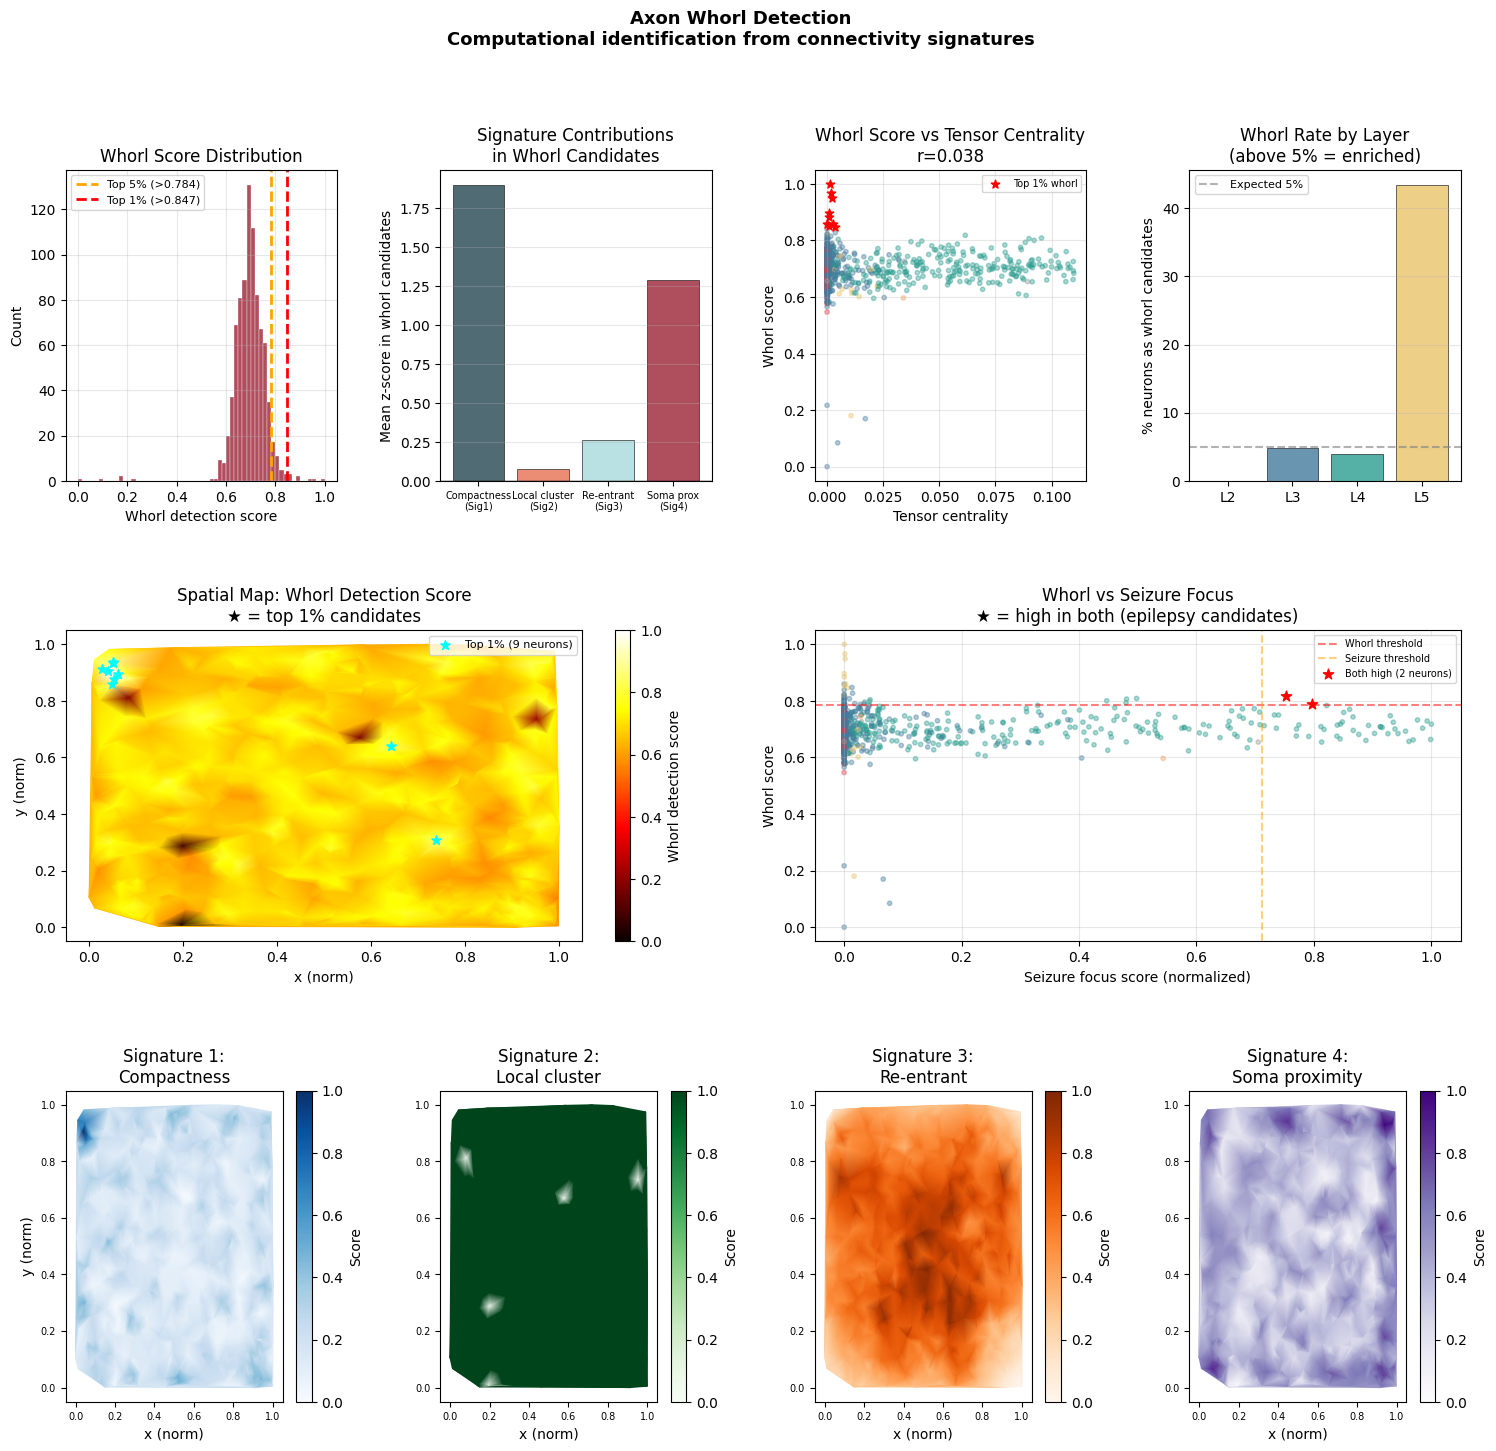

Saved: whorl_detection.png

Key finding: 2 neurons are high in BOTH whorl score AND seizure focus score
These are the primary epilepsy investigation targets


In [ ]:
# ============================================================
# VISUALIZE WHORL DETECTION
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.tri import Triangulation
from matplotlib.lines import Line2D
import numpy as np

fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 4, figure=fig,
                         hspace=0.48, wspace=0.38)

layer_colors_map = {
    'Layer 1':'#F4A261','Layer 2':'#E63946',
    'Layer 3':'#457B9D','Layer 4':'#2A9D8F',
    'Layer 5':'#E9C46A','White matter':'#6D6875',
    'unclassified':'#999999'
}
node_colors = [layer_colors_map.get(l,'#999')
               for l in layer_labels]
triang = Triangulation(coords_norm[:,0],
                        coords_norm[:,1], triangles)

# ── Plot 1: Whorl score distribution ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(whorl_score_norm, bins=60,
         color='#9B2335', alpha=0.8, edgecolor='white',
         linewidth=0.3)
ax1.axvline(x=threshold_95, color='orange',
            linestyle='--', linewidth=2,
            label=f'Top 5% (>{threshold_95:.3f})')
ax1.axvline(x=threshold_99, color='red',
            linestyle='--', linewidth=2,
            label=f'Top 1% (>{threshold_99:.3f})')
ax1.set_xlabel('Whorl detection score')
ax1.set_ylabel('Count')
ax1.set_title('Whorl Score Distribution')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── Plot 2: Per-signature contribution ───────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sig_names = ['Compactness\n(Sig1)',
             'Local cluster\n(Sig2)',
             'Re-entrant\n(Sig3)',
             'Soma prox\n(Sig4)']
sig_means_whorl = [
    sig1_z[whorl_candidates_95].mean(),
    sig2_z[whorl_candidates_95].mean(),
    sig3_z[whorl_candidates_95].mean(),
    sig4_z[whorl_candidates_95].mean()
]
sig_means_all = [0, 0, 0, 0]  # z-scores mean to 0 by def
colors_sig = ['#264653','#E76F51','#A8DADC','#9B2335']
ax2.bar(sig_names, sig_means_whorl, color=colors_sig,
        alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.set_ylabel('Mean z-score in whorl candidates')
ax2.set_title('Signature Contributions\nin Whorl Candidates')
ax2.grid(alpha=0.3, axis='y')
ax2.tick_params(axis='x', labelsize=7)

# ── Plot 3: Whorl score vs tensor centrality ──────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(tensor_centrality, whorl_score_norm,
            c=node_colors, alpha=0.4, s=10)
ax3.scatter(tensor_centrality[whorl_candidates_99],
            whorl_score_norm[whorl_candidates_99],
            c='red', s=40, marker='*', zorder=5,
            label='Top 1% whorl')
ax3.set_xlabel('Tensor centrality')
ax3.set_ylabel('Whorl score')
ax3.set_title(f'Whorl Score vs Tensor Centrality\n'
              f'r={r_whorl_seizure:.3f}')
ax3.legend(fontsize=7); ax3.grid(alpha=0.3)

# ── Plot 4: Per-layer whorl rate ──────────────────────────────
ax4 = fig.add_subplot(gs[0, 3])
layers_plot = ['Layer 2','Layer 3','Layer 4','Layer 5']
whorl_rates = []
for l in layers_plot:
    lmask  = layer_labels == l
    total  = lmask.sum()
    n_wh   = (whorl_score_norm[lmask] >= threshold_95).sum()
    whorl_rates.append(n_wh / total * 100 if total > 0 else 0)
bar_colors = [layer_colors_map.get(l,'#999')
               for l in layers_plot]
ax4.bar([l.replace('Layer ','L') for l in layers_plot],
        whorl_rates, color=bar_colors, alpha=0.8,
        edgecolor='black', linewidth=0.5)
ax4.axhline(y=5.0, color='gray', linestyle='--',
            alpha=0.6, label='Expected 5%')
ax4.set_ylabel('% neurons as whorl candidates')
ax4.set_title('Whorl Rate by Layer\n(above 5% = enriched)')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3, axis='y')

# ── Plot 5: Spatial map of whorl score ────────────────────────
ax5 = fig.add_subplot(gs[1, :2])
sc5 = ax5.tripcolor(triang, whorl_score_norm,
                    cmap='hot', shading='gouraud')
plt.colorbar(sc5, ax=ax5, label='Whorl detection score')
# Mark top 1% candidates
ax5.scatter(
    coords_norm[whorl_candidates_99, 0],
    coords_norm[whorl_candidates_99, 1],
    c='cyan', s=50, marker='*', zorder=6,
    label=f'Top 1% ({len(whorl_candidates_99)} neurons)')
ax5.set_title('Spatial Map: Whorl Detection Score\n'
              '★ = top 1% candidates')
ax5.set_xlabel('x (norm)'); ax5.set_ylabel('y (norm)')
ax5.legend(fontsize=8)

# ── Plot 6: Whorl score vs seizure focus overlay ──────────────
ax6 = fig.add_subplot(gs[1, 2:])
seizure_norm = seizure_score / seizure_score.max()
ax6.scatter(seizure_norm, whorl_score_norm,
            c=node_colors, alpha=0.4, s=10)
# Quadrant lines
ax6.axhline(y=threshold_95, color='red',
            linestyle='--', alpha=0.5,
            label='Whorl threshold')
ax6.axvline(x=np.percentile(seizure_norm, 95),
            color='orange', linestyle='--', alpha=0.5,
            label='Seizure threshold')
# Highlight top-right quadrant (both high)
both_high = np.where(
    (whorl_score_norm >= threshold_95) &
    (seizure_norm >= np.percentile(seizure_norm, 95)))[0]
if len(both_high) > 0:
    ax6.scatter(seizure_norm[both_high],
                whorl_score_norm[both_high],
                c='red', s=60, marker='*', zorder=6,
                label=f'Both high ({len(both_high)} neurons)')
ax6.set_xlabel('Seizure focus score (normalized)')
ax6.set_ylabel('Whorl score')
ax6.set_title('Whorl vs Seizure Focus\n'
              '★ = high in both (epilepsy candidates)')
ax6.legend(fontsize=7); ax6.grid(alpha=0.3)

# ── Plot 7: Individual signature spatial maps ─────────────────
sig_data = [
    (sig1_z, 'Compactness', 'Blues'),
    (sig2_z, 'Local cluster', 'Greens'),
    (sig3_z, 'Re-entrant', 'Oranges'),
    (sig4_z, 'Soma proximity', 'Purples')
]
for idx, (sig, name, cmap) in enumerate(sig_data):
    ax = fig.add_subplot(gs[2, idx])
    sig_norm = (sig - sig.min()) / (sig.max() - sig.min())
    sc = ax.tripcolor(triang, sig_norm, cmap=cmap,
                      shading='gouraud')
    plt.colorbar(sc, ax=ax, label='Score')
    ax.set_title(f'Signature {idx+1}:\n{name}')
    ax.set_xlabel('x (norm)')
    ax.set_ylabel('y (norm)' if idx == 0 else '')
    ax.tick_params(labelsize=7)

plt.suptitle('Axon Whorl Detection\n'
             'Computational identification from '
             'connectivity signatures',
             fontsize=13, fontweight='bold')
plt.savefig('whorl_detection.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: whorl_detection.png")
print(f"\nKey finding: {len(both_high)} neurons are "
      f"high in BOTH whorl score AND seizure focus score")
print(f"These are the primary epilepsy investigation targets")

In [ ]:
# ============================================================
# NOVEL ANOMALY DETECTION
# ============================================================
# Beyond whorls, we look for two classes of structural anomaly:
#
# ANOMALY 1 — TERRITORY VIOLATIONS (dysplastic neurons)
#   Neurons whose connectivity signature places them in the
#   wrong functional territory for their layer.
#   Expected: Layer 4 → routing territory (high Pyr centrality)
#             Layer 2 → integration territory (high Int centrality)
#   Violation: Layer 4 neuron with high Integration centrality
#              Layer 2 neuron with high Pyramidal centrality
#   Biological meaning: dysplastic or misplaced neurons —
#   known feature of focal cortical dysplasia in epilepsy
#
# ANOMALY 2 — CONNECTIVITY ORPHANS (pruned/lost synapses)
#   Neurons with abnormally LOW connectivity relative to
#   spatial neighbors — potential sites of synaptic loss
#   Biological meaning: chronic epileptic activity causes
#   selective synaptic pruning and cell loss
#
# ANOMALY 3 — HYPEREDGE GIANTS (hyperconnected hubs)
#   Neurons appearing in far more hyperedges than expected
#   for their spatial location — abnormal hub formation
#   Biological meaning: compensatory sprouting after seizures,
#   or pre-existing malformation driving hyperexcitability
#
# ANOMALY 4 — GLIAL ISOLATION (neuroinflammatory signature)
#   Neurons with high MG_OPC surveillance but LOW neuronal
#   connectivity — being monitored but functionally isolated
#   Biological meaning: neurons targeted for immune-mediated
#   elimination in chronic neuroinflammation
# ============================================================

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import zscore, percentileofscore
from scipy.spatial import cKDTree

print("Running novel anomaly detection...")
print(f"Working on {n_nodes} interneurons in patch\n")

# ── Setup: rebuild needed variables ──────────────────────────
inter_coords_full = np.array([
    [patch.loc[n]['x'], patch.loc[n]['y'], patch.loc[n]['z']]
    for n in all_nodes
])
inter_tree_full = cKDTree(inter_coords_full)

# MG_OPC centrality — rebuild if needed
if 'cent_mgopc' not in globals():
    print("Rebuilding cent_mgopc...")
    x_bounds = (patch['x'].min(), patch['x'].max())
    y_bounds = (patch['y'].min(), patch['y'].max())
    z_bounds = (patch['z'].min(), patch['z'].max())
    mgopc_df_local = somas[
        (somas['celltype'] == 'MG_OPC') &
        (somas['x'] >= x_bounds[0]) &
        (somas['x'] <= x_bounds[1]) &
        (somas['y'] >= y_bounds[0]) &
        (somas['y'] <= y_bounds[1]) &
        (somas['z'] >= z_bounds[0]) &
        (somas['z'] <= z_bounds[1])
    ].copy()
    all_neuron_coords = np.array([
        [patch.loc[n]['x'], patch.loc[n]['y'],
         patch.loc[n]['z']] for n in all_nodes])
    all_neuron_tree = cKDTree(all_neuron_coords)
    B5r, B5c, s5 = [], [], []
    for mi, (mg_id, mrow) in enumerate(
            mgopc_df_local.iterrows()):
        mc = np.array([mrow['x'], mrow['y'], mrow['z']])
        nearby = all_neuron_tree.query_ball_point(mc, 15000)
        local  = [i for i in nearby if i < n_nodes]
        if len(local) < 2:
            continue
        for ii in local:
            B5r.append(mi); B5c.append(ii)
        s5.append(max(len(local), 1))
    if B5r:
        B5_vals = np.array([
            1.0/np.sqrt(s5[min(r, len(s5)-1)])
            for r in range(len(B5r))], dtype=np.float32)
        B5 = sp.csr_matrix(
            (B5_vals,
             (np.array(B5r, dtype=np.int32),
              np.array(B5c, dtype=np.int32))),
            shape=(len(mgopc_df_local), n_nodes),
            dtype=np.float32)
        C5 = (B5.T @ B5).tocsr()
        C5.setdiag(0); C5.eliminate_zeros()
    else:
        C5 = sp.csr_matrix((n_nodes, n_nodes))
    cent_mgopc = power_iteration_centrality(C5)
    print(f"  cent_mgopc: mean={cent_mgopc.mean():.4f}")

# ── ANOMALY 1: Territory violations ──────────────────────────
print("Detecting Anomaly 1: Territory violations...")

# Expected territory per layer
# Layer 4 → high pyramidal centrality (routing)
# Layer 2 → high integration centrality (convergence)
# Layer 3 → moderate both (relay)
# Violation = neuron in wrong territory for its layer

# Normalize centralities to [0,1]
pyr_norm = (cent_pyr - cent_pyr.min()) / (
    cent_pyr.max() - cent_pyr.min() + 1e-10)
int_norm = (cent_int - cent_int.min()) / (
    cent_int.max() - cent_int.min() + 1e-10)

# Territory assignment: routing vs integration
# routing_score > 0 = routing territory
# routing_score < 0 = integration territory
routing_score = pyr_norm - int_norm

# Expected sign per layer
layer_expected = {
    'Layer 2': -1,   # should be integration (negative)
    'Layer 3':  0,   # neutral
    'Layer 4': +1,   # should be routing (positive)
    'Layer 5': +1,   # should be routing (positive)
}

territory_violation = np.zeros(n_nodes)
expected_sign       = np.zeros(n_nodes)

for i, node in enumerate(all_nodes):
    l    = layer_labels[i]
    exp  = layer_expected.get(l, 0)
    actual_sign = np.sign(routing_score[i])
    expected_sign[i] = exp
    if exp != 0 and actual_sign != exp:
        # Violation — magnitude = how far into wrong territory
        territory_violation[i] = abs(routing_score[i])

n_violations = (territory_violation > 0).sum()
print(f"  Territory violations: {n_violations} "
      f"({n_violations/n_nodes*100:.1f}%)")

# Per-layer violation rate
for l in ['Layer 2','Layer 3','Layer 4','Layer 5']:
    lmask = layer_labels == l
    if lmask.sum() == 0:
        continue
    n_viol = (territory_violation[lmask] > 0).sum()
    print(f"  {l}: {n_viol}/{lmask.sum()} "
          f"({n_viol/lmask.sum()*100:.1f}%) violations")

# ── ANOMALY 2: Connectivity orphans ──────────────────────────
print("\nDetecting Anomaly 2: Connectivity orphans...")

# For each neuron, compare its connectivity to spatial neighbors
# Orphan = neuron with much lower connectivity than neighbors
neighbor_radius = 20000   # 20μm neighborhood

orphan_score = np.zeros(n_nodes)
hyperdeg_arr = np.array([node_degree[n] for n in all_nodes],
                         dtype=float)

for i in range(n_nodes):
    neighbors = inter_tree_full.query_ball_point(
        inter_coords_full[i], neighbor_radius)
    neighbors = [j for j in neighbors if j != i]
    if len(neighbors) < 3:
        continue
    neighbor_mean = hyperdeg_arr[neighbors].mean()
    neighbor_std  = hyperdeg_arr[neighbors].std()
    if neighbor_std < 1e-6:
        continue
    # Z-score relative to neighborhood
    z = (hyperdeg_arr[i] - neighbor_mean) / neighbor_std
    # Orphan = much lower than neighbors (negative z)
    orphan_score[i] = max(-z, 0)

orphan_norm = (orphan_score - orphan_score.min()) / (
    orphan_score.max() - orphan_score.min() + 1e-10)

n_orphans = (orphan_norm >= np.percentile(
    orphan_norm, 95)).sum()
print(f"  Orphan candidates (top 5%): {n_orphans}")

# Per-layer orphan rate
for l in ['Layer 2','Layer 3','Layer 4','Layer 5']:
    lmask = layer_labels == l
    if lmask.sum() == 0:
        continue
    thresh = np.percentile(orphan_norm, 95)
    n_orp  = (orphan_norm[lmask] >= thresh).sum()
    print(f"  {l}: {n_orp} orphans "
          f"({n_orp/lmask.sum()*100:.1f}%)")

# ── ANOMALY 3: Hyperedge giants ───────────────────────────────
print("\nDetecting Anomaly 3: Hyperedge giants...")

# Expected hyperdegree given spatial density
# Giant = much higher degree than spatially expected
giant_score = np.zeros(n_nodes)

for i in range(n_nodes):
    neighbors = inter_tree_full.query_ball_point(
        inter_coords_full[i], neighbor_radius)
    neighbors = [j for j in neighbors if j != i]
    if len(neighbors) < 3:
        continue
    neighbor_mean = hyperdeg_arr[neighbors].mean()
    neighbor_std  = hyperdeg_arr[neighbors].std()
    if neighbor_std < 1e-6:
        continue
    z = (hyperdeg_arr[i] - neighbor_mean) / neighbor_std
    giant_score[i] = max(z, 0)

giant_norm = (giant_score - giant_score.min()) / (
    giant_score.max() - giant_score.min() + 1e-10)

n_giants = (giant_norm >= np.percentile(
    giant_norm, 95)).sum()
print(f"  Hyperedge giant candidates (top 5%): {n_giants}")

for l in ['Layer 2','Layer 3','Layer 4','Layer 5']:
    lmask = layer_labels == l
    if lmask.sum() == 0:
        continue
    thresh = np.percentile(giant_norm, 95)
    n_g    = (giant_norm[lmask] >= thresh).sum()
    print(f"  {l}: {n_g} giants "
          f"({n_g/lmask.sum()*100:.1f}%)")

# ── ANOMALY 4: Glial isolation ────────────────────────────────
print("\nDetecting Anomaly 4: Glial isolation...")

# High MG_OPC surveillance + low neuronal connectivity
mgopc_norm = (cent_mgopc - cent_mgopc.min()) / (
    cent_mgopc.max() - cent_mgopc.min() + 1e-10)
pyr_norm_conn = (cent_pyr - cent_pyr.min()) / (
    cent_pyr.max() - cent_pyr.min() + 1e-10)

# Glial isolation = high surveillance, low connectivity
glial_isolation = mgopc_norm * (1 - pyr_norm_conn)
glial_norm = (glial_isolation - glial_isolation.min()) / (
    glial_isolation.max() - glial_isolation.min() + 1e-10)

n_isolated = (glial_norm >= np.percentile(
    glial_norm, 95)).sum()
print(f"  Glially isolated candidates (top 5%): {n_isolated}")

for l in ['Layer 2','Layer 3','Layer 4','Layer 5']:
    lmask = layer_labels == l
    if lmask.sum() == 0:
        continue
    thresh = np.percentile(glial_norm, 95)
    n_iso  = (glial_norm[lmask] >= thresh).sum()
    print(f"  {l}: {n_iso} isolated "
          f"({n_iso/lmask.sum()*100:.1f}%)")

# ── Combined anomaly score ────────────────────────────────────
print("\nBuilding combined anomaly profile...")

# Normalize territory violation
terr_norm = (territory_violation - territory_violation.min()) / (
    territory_violation.max() -
    territory_violation.min() + 1e-10)

combined_anomaly = (
    terr_norm    * 0.30 +   # territory violation
    orphan_norm  * 0.25 +   # connectivity loss
    giant_norm   * 0.25 +   # hyperconnection
    glial_norm   * 0.20     # immune targeting
)
combined_anomaly /= combined_anomaly.max()

# Also include whorl score
combined_with_whorl = (
    combined_anomaly * 0.70 +
    whorl_score_norm * 0.30
)
combined_with_whorl /= combined_with_whorl.max()

thresh_anomaly = np.percentile(combined_anomaly, 95)
thresh_whorl_c = np.percentile(combined_with_whorl, 95)

anomaly_candidates = np.where(
    combined_anomaly >= thresh_anomaly)[0]
full_candidates    = np.where(
    combined_with_whorl >= thresh_whorl_c)[0]

print(f"\nAnomaly candidates (top 5%): "
      f"{len(anomaly_candidates)}")
print(f"Full candidates (anomaly + whorl, top 5%): "
      f"{len(full_candidates)}")

# ── Overlap with seizure focus ────────────────────────────────
seizure_combined = cent_pyr * cent_mgopc
seizure_thresh   = np.percentile(seizure_combined, 95)

overlap_seizure_anomaly = np.where(
    (combined_anomaly >= thresh_anomaly) &
    (seizure_combined >= seizure_thresh))[0]

overlap_seizure_whorl = np.where(
    (whorl_score_norm >= np.percentile(
        whorl_score_norm, 95)) &
    (seizure_combined >= seizure_thresh))[0]

overlap_all_three = np.where(
    (combined_anomaly >= thresh_anomaly) &
    (whorl_score_norm >= np.percentile(
        whorl_score_norm, 95)) &
    (seizure_combined >= seizure_thresh))[0]

print(f"\nOverlap analysis (epilepsy targets):")
print(f"  Seizure focus ∩ Structural anomaly: "
      f"{len(overlap_seizure_anomaly)} neurons")
print(f"  Seizure focus ∩ Whorl: "
      f"{len(overlap_seizure_whorl)} neurons")
print(f"  All three (seizure ∩ anomaly ∩ whorl): "
      f"{len(overlap_all_three)} neurons")

if len(overlap_all_three) > 0:
    print(f"\n  CRITICAL TARGETS (all 3 criteria):")
    print(f"  {'Node':>6} {'Layer':>12} "
          f"{'Anomaly':>10} {'Whorl':>10} "
          f"{'Seizure':>10}")
    print(f"  {'-'*54}")
    for ti in overlap_all_three:
        orig = all_nodes[ti]
        print(f"  {orig:>6} "
              f"{layer_labels[ti]:>12} "
              f"{combined_anomaly[ti]:>10.4f} "
              f"{whorl_score_norm[ti]:>10.4f} "
              f"{seizure_combined[ti]:>10.6f}")

# Per-layer anomaly summary table
print(f"\nFull anomaly summary by layer:")
print(f"  {'Layer':>10} {'Territory':>12} "
      f"{'Orphan':>10} {'Giant':>10} "
      f"{'Glial':>10} {'Whorl':>10}")
print(f"  {'-'*64}")
for l in ['Layer 2','Layer 3','Layer 4','Layer 5']:
    lmask = layer_labels == l
    if lmask.sum() == 0:
        continue
    t95_terr  = np.percentile(terr_norm, 95)
    t95_orp   = np.percentile(orphan_norm, 95)
    t95_giant = np.percentile(giant_norm, 95)
    t95_glial = np.percentile(glial_norm, 95)
    t95_whorl = np.percentile(whorl_score_norm, 95)

    n_t = (terr_norm[lmask]  >= t95_terr).sum()
    n_o = (orphan_norm[lmask] >= t95_orp).sum()
    n_g = (giant_norm[lmask]  >= t95_giant).sum()
    n_gl= (glial_norm[lmask]  >= t95_glial).sum()
    n_w = (whorl_score_norm[lmask] >= t95_whorl).sum()

    print(f"  {l:>10} {n_t:>12} {n_o:>10} "
          f"{n_g:>10} {n_gl:>10} {n_w:>10}")

Running novel anomaly detection...
Working on 852 interneurons in patch

Detecting Anomaly 1: Territory violations...
  Territory violations: 0 (0.0%)
  Layer 2: 0/92 (0.0%) violations
  Layer 3: 0/457 (0.0%) violations
  Layer 4: 0/275 (0.0%) violations
  Layer 5: 0/23 (0.0%) violations

Detecting Anomaly 2: Connectivity orphans...
  Orphan candidates (top 5%): 43
  Layer 2: 9 orphans (9.8%)
  Layer 3: 26 orphans (5.7%)
  Layer 4: 6 orphans (2.2%)
  Layer 5: 2 orphans (8.7%)

Detecting Anomaly 3: Hyperedge giants...
  Hyperedge giant candidates (top 5%): 43
  Layer 2: 16 giants (17.4%)
  Layer 3: 1 giants (0.2%)
  Layer 4: 26 giants (9.5%)
  Layer 5: 0 giants (0.0%)

Detecting Anomaly 4: Glial isolation...
  Glially isolated candidates (top 5%): 43
  Layer 2: 0 isolated (0.0%)
  Layer 3: 34 isolated (7.4%)
  Layer 4: 9 isolated (3.3%)
  Layer 5: 0 isolated (0.0%)

Building combined anomaly profile...

Anomaly candidates (top 5%): 43
Full candidates (anomaly + whorl, top 5%): 43

Overl

/tmp/ipykernel_22937/2521497955.py:148: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(anomaly_arr[:,i],
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


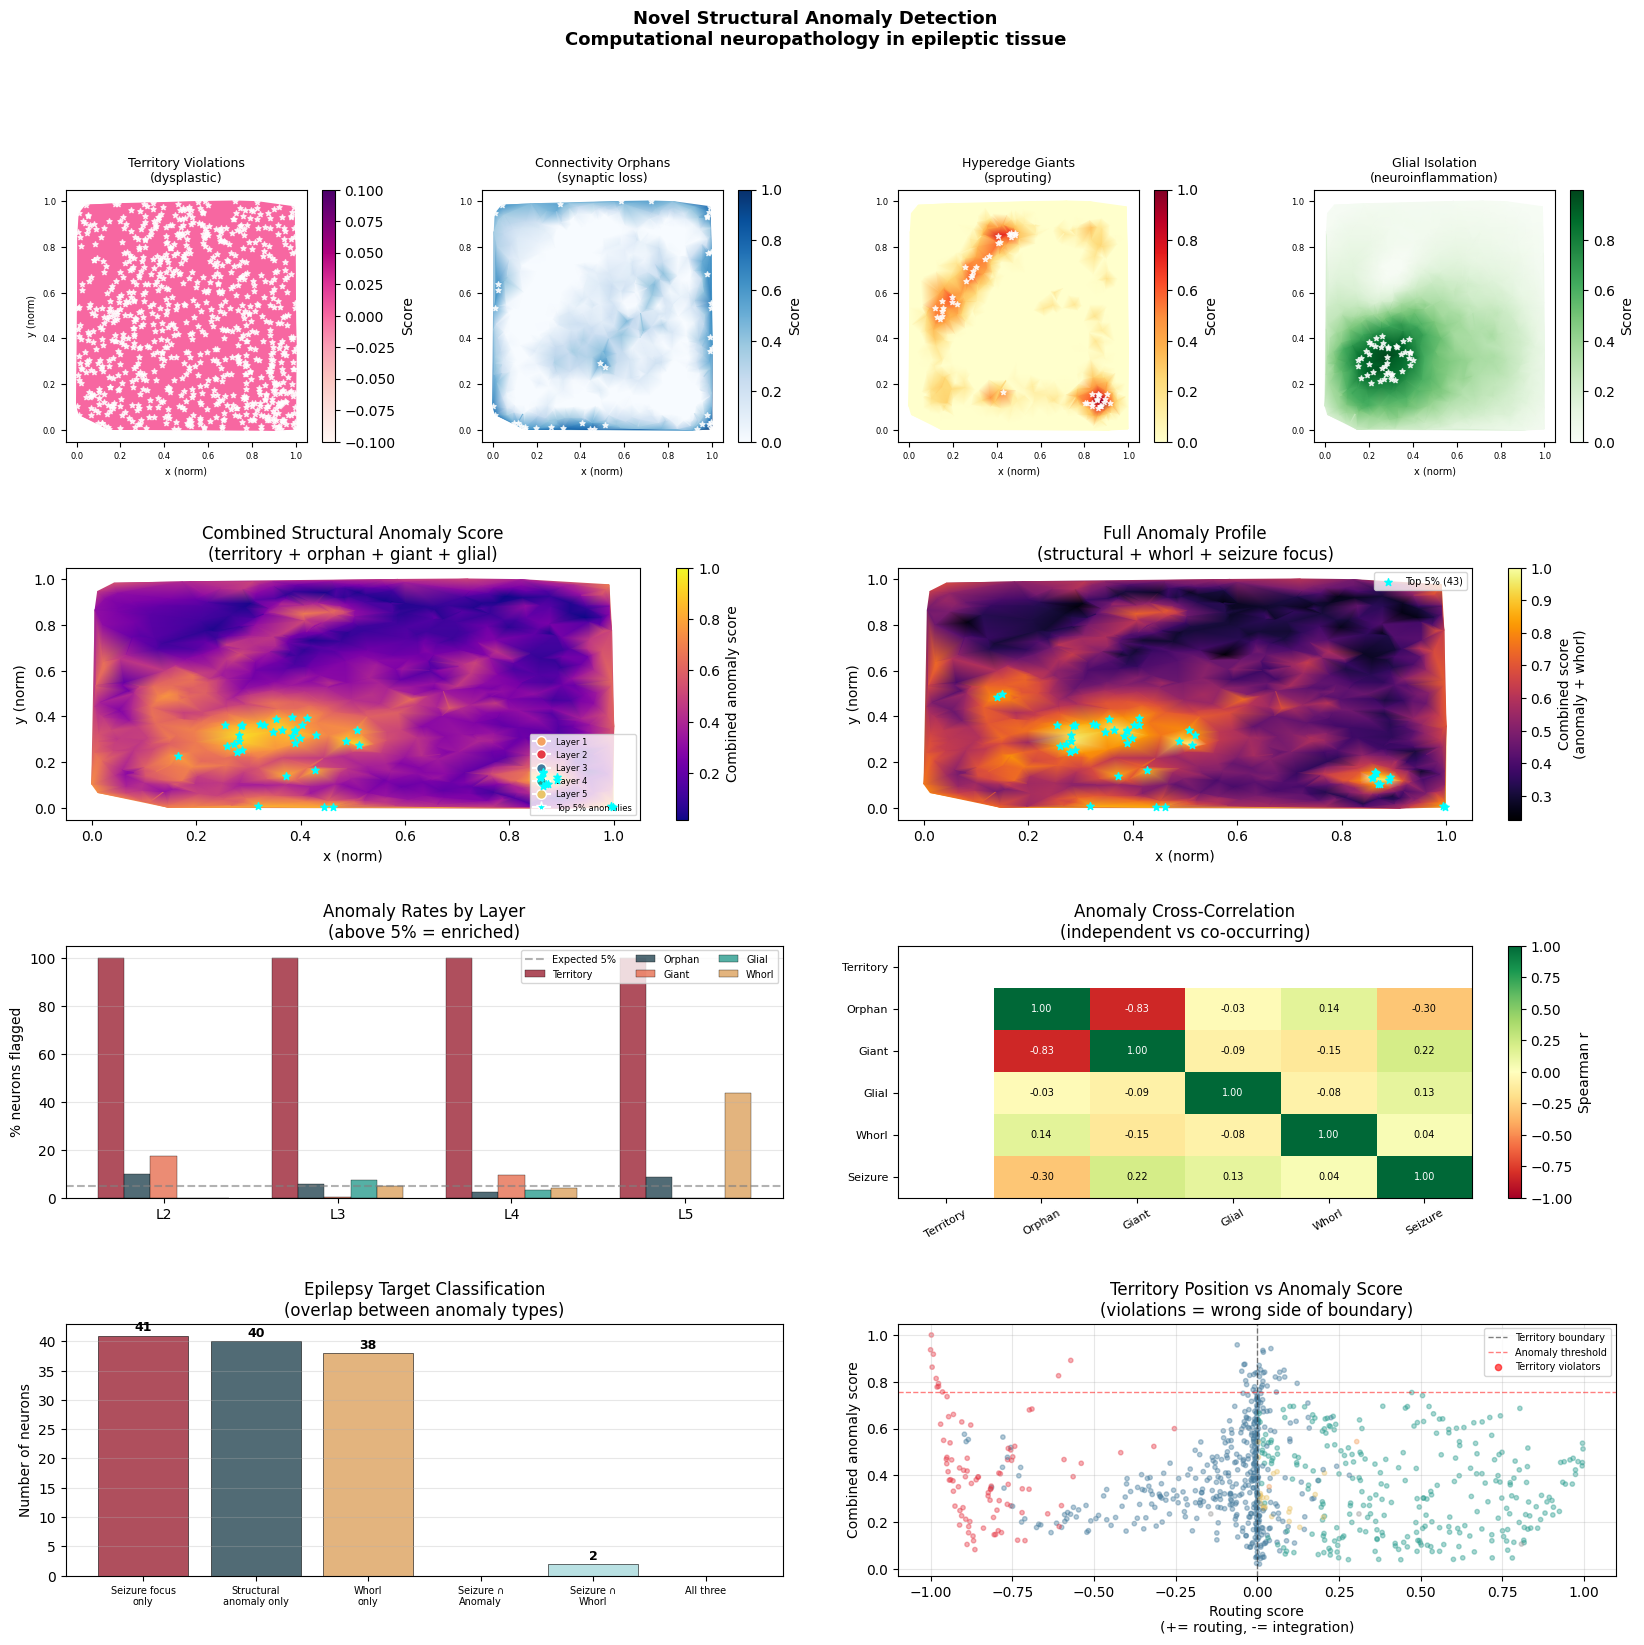

Saved: novel_anomalies.png

Final epilepsy target count:
  Neurons flagged by all 3 criteria: 0
  Seizure focus + anomaly:           0
  Seizure focus + whorl:             2


In [ ]:
# ============================================================
# VISUALIZE NOVEL ANOMALIES
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.tri import Triangulation
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(4, 4, figure=fig,
                         hspace=0.50, wspace=0.38)

layer_colors_map = {
    'Layer 1':'#F4A261','Layer 2':'#E63946',
    'Layer 3':'#457B9D','Layer 4':'#2A9D8F',
    'Layer 5':'#E9C46A','White matter':'#6D6875',
    'unclassified':'#999999'
}
node_colors = [layer_colors_map.get(l,'#999')
               for l in layer_labels]
triang = Triangulation(coords_norm[:,0],
                        coords_norm[:,1], triangles)

# ── Row 1: Individual anomaly spatial maps ────────────────────
anomaly_maps = [
    (terr_norm,   'Territory Violations\n(dysplastic)',  'RdPu'),
    (orphan_norm, 'Connectivity Orphans\n(synaptic loss)', 'Blues'),
    (giant_norm,  'Hyperedge Giants\n(sprouting)',       'YlOrRd'),
    (glial_norm,  'Glial Isolation\n(neuroinflammation)','Greens')
]
for idx, (data, title, cmap) in enumerate(anomaly_maps):
    ax = fig.add_subplot(gs[0, idx])
    sc = ax.tripcolor(triang, data, cmap=cmap,
                      shading='gouraud')
    plt.colorbar(sc, ax=ax, label='Score')
    # Mark top 5%
    thresh = np.percentile(data, 95)
    cands  = np.where(data >= thresh)[0]
    ax.scatter(coords_norm[cands, 0],
               coords_norm[cands, 1],
               c='white', s=15, marker='*',
               zorder=5, alpha=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x (norm)', fontsize=7)
    ax.set_ylabel('y (norm)' if idx==0 else '',
                  fontsize=7)
    ax.tick_params(labelsize=6)

# ── Plot 5: Combined anomaly spatial map ─────────────────────
ax5 = fig.add_subplot(gs[1, :2])
sc5 = ax5.tripcolor(triang, combined_anomaly,
                    cmap='plasma', shading='gouraud')
plt.colorbar(sc5, ax=ax5,
             label='Combined anomaly score')
ax5.scatter(
    coords_norm[anomaly_candidates, 0],
    coords_norm[anomaly_candidates, 1],
    c='cyan', s=30, marker='*', zorder=6,
    label=f'Top 5% anomalies ({len(anomaly_candidates)})')
ax5.set_title('Combined Structural Anomaly Score\n'
              '(territory + orphan + giant + glial)')
ax5.set_xlabel('x (norm)'); ax5.set_ylabel('y (norm)')
ax5.legend(fontsize=7)

# ── Plot 6: Full candidate map (anomaly + whorl) ──────────────
ax6 = fig.add_subplot(gs[1, 2:])
sc6 = ax6.tripcolor(triang, combined_with_whorl,
                    cmap='inferno', shading='gouraud')
plt.colorbar(sc6, ax=ax6,
             label='Combined score\n(anomaly + whorl)')
ax6.scatter(
    coords_norm[full_candidates, 0],
    coords_norm[full_candidates, 1],
    c='cyan', s=30, marker='*', zorder=6,
    label=f'Top 5% ({len(full_candidates)})')
if len(overlap_all_three) > 0:
    ax6.scatter(
        coords_norm[overlap_all_three, 0],
        coords_norm[overlap_all_three, 1],
        c='red', s=80, marker='*', zorder=7,
        label=f'All 3 criteria ({len(overlap_all_three)})')
ax6.set_title('Full Anomaly Profile\n'
              '(structural + whorl + seizure focus)')
ax6.set_xlabel('x (norm)'); ax6.set_ylabel('y (norm)')
ax6.legend(fontsize=7)

# ── Plot 7: Per-layer anomaly rates ──────────────────────────
ax7 = fig.add_subplot(gs[2, :2])
layers_plot  = ['Layer 2','Layer 3','Layer 4','Layer 5']
anomaly_types = {
    'Territory': terr_norm,
    'Orphan':    orphan_norm,
    'Giant':     giant_norm,
    'Glial':     glial_norm,
    'Whorl':     whorl_score_norm
}
anom_colors = ['#9B2335','#264653','#E76F51',
               '#2A9D8F','#DDA15E']
x_pos = np.arange(len(layers_plot))
width = 0.15

for ki, (aname, adata) in enumerate(
        anomaly_types.items()):
    thresh = np.percentile(adata, 95)
    rates  = []
    for l in layers_plot:
        lmask = layer_labels == l
        if lmask.sum() == 0:
            rates.append(0)
            continue
        rates.append(
            (adata[lmask] >= thresh).sum() /
            lmask.sum() * 100)
    offset = (ki - 2) * width
    ax7.bar(x_pos + offset, rates, width,
            label=aname, color=anom_colors[ki],
            alpha=0.8, edgecolor='black',
            linewidth=0.3)

ax7.axhline(y=5.0, color='gray', linestyle='--',
            alpha=0.6, label='Expected 5%')
ax7.set_xticks(x_pos)
ax7.set_xticklabels([l.replace('Layer ','L')
                      for l in layers_plot])
ax7.set_ylabel('% neurons flagged')
ax7.set_title('Anomaly Rates by Layer\n'
              '(above 5% = enriched)')
ax7.legend(fontsize=7, ncol=3)
ax7.grid(alpha=0.3, axis='y')

# ── Plot 8: Anomaly correlation matrix ───────────────────────
ax8 = fig.add_subplot(gs[2, 2:])
from scipy.stats import spearmanr
anomaly_arr = np.column_stack([
    terr_norm, orphan_norm, giant_norm,
    glial_norm, whorl_score_norm,
    seizure_combined / seizure_combined.max()
])
anom_names = ['Territory','Orphan','Giant',
              'Glial','Whorl','Seizure']
corr_anom = np.zeros((6, 6))
for i in range(6):
    for j in range(6):
        r, _ = spearmanr(anomaly_arr[:,i],
                          anomaly_arr[:,j])
        corr_anom[i,j] = r

im8 = ax8.imshow(corr_anom, cmap='RdYlGn',
                  vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im8, ax=ax8, label='Spearman r')
ax8.set_xticks(range(6))
ax8.set_yticks(range(6))
ax8.set_xticklabels(anom_names, fontsize=8,
                     rotation=30)
ax8.set_yticklabels(anom_names, fontsize=8)
ax8.set_title('Anomaly Cross-Correlation\n'
              '(independent vs co-occurring)')
for i in range(6):
    for j in range(6):
        ax8.text(j, i, f'{corr_anom[i,j]:.2f}',
                 ha='center', va='center',
                 fontsize=7,
                 color='black'
                 if abs(corr_anom[i,j]) < 0.6
                 else 'white')

# ── Plot 9: Epilepsy target summary ──────────────────────────
ax9 = fig.add_subplot(gs[3, :2])
categories = [
    'Seizure focus\nonly',
    'Structural\nanomaly only',
    'Whorl\nonly',
    'Seizure ∩\nAnomaly',
    'Seizure ∩\nWhorl',
    'All three'
]
t95_a = np.percentile(combined_anomaly, 95)
t95_w = np.percentile(whorl_score_norm, 95)
t95_s = np.percentile(seizure_combined, 95)

s_only = ((seizure_combined >= t95_s) &
          (combined_anomaly < t95_a) &
          (whorl_score_norm < t95_w)).sum()
a_only = ((combined_anomaly >= t95_a) &
          (seizure_combined < t95_s) &
          (whorl_score_norm < t95_w)).sum()
w_only = ((whorl_score_norm >= t95_w) &
          (seizure_combined < t95_s) &
          (combined_anomaly < t95_a)).sum()
sa = ((seizure_combined >= t95_s) &
      (combined_anomaly >= t95_a) &
      (whorl_score_norm < t95_w)).sum()
sw = ((seizure_combined >= t95_s) &
      (whorl_score_norm >= t95_w) &
      (combined_anomaly < t95_a)).sum()
all3 = len(overlap_all_three)

counts = [s_only, a_only, w_only, sa, sw, all3]
bar_c  = ['#9B2335','#264653','#DDA15E',
          '#E76F51','#A8DADC','red']
bars   = ax9.bar(categories, counts, color=bar_c,
                  alpha=0.8, edgecolor='black',
                  linewidth=0.5)
ax9.set_ylabel('Number of neurons')
ax9.set_title('Epilepsy Target Classification\n'
              '(overlap between anomaly types)')
ax9.grid(alpha=0.3, axis='y')
for bar, count in zip(bars, counts):
    if count > 0:
        ax9.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 str(count), ha='center',
                 va='bottom', fontsize=9,
                 fontweight='bold')
ax9.tick_params(axis='x', labelsize=7)

# ── Plot 10: Routing score vs anomaly score ───────────────────
ax10 = fig.add_subplot(gs[3, 2:])
sc10 = ax10.scatter(
    routing_score, combined_anomaly,
    c=node_colors, alpha=0.4, s=10)
ax10.axvline(x=0, color='black', linewidth=1,
             linestyle='--', alpha=0.5,
             label='Territory boundary')
ax10.axhline(y=t95_a, color='red',
             linewidth=1, linestyle='--',
             alpha=0.5, label='Anomaly threshold')
# Highlight violations
viol_idx = np.where(territory_violation > 0)[0]
ax10.scatter(routing_score[viol_idx],
             combined_anomaly[viol_idx],
             c='red', s=20, alpha=0.6,
             zorder=5, label='Territory violators')
ax10.set_xlabel('Routing score\n'
                '(+= routing, -= integration)')
ax10.set_ylabel('Combined anomaly score')
ax10.set_title('Territory Position vs Anomaly Score\n'
               '(violations = wrong side of boundary)')
ax10.legend(fontsize=7); ax10.grid(alpha=0.3)

legend_els = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=c, markersize=7, label=l)
    for l, c in layer_colors_map.items()
    if (layer_labels==l).sum() > 0]
ax5.legend(handles=legend_els + [
    Line2D([0],[0], marker='*', color='w',
           markerfacecolor='cyan', markersize=8,
           label='Top 5% anomalies')],
    fontsize=6, loc='lower right')

plt.suptitle('Novel Structural Anomaly Detection\n'
             'Computational neuropathology in '
             'epileptic tissue',
             fontsize=13, fontweight='bold')
plt.savefig('novel_anomalies.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: novel_anomalies.png")
print(f"\nFinal epilepsy target count:")
print(f"  Neurons flagged by all 3 criteria: "
      f"{len(overlap_all_three)}")
print(f"  Seizure focus + anomaly:           {sa}")
print(f"  Seizure focus + whorl:             {sw}")

In [ ]:
import numpy as np
from scipy.stats import entropy
from scipy.spatial import cKDTree

# ── Connectivity profile diagnostic ──────────────────────────
print("Connectivity profile diagnostic...")

inter_coords_full = np.array([
    [patch.loc[n]['x'], patch.loc[n]['y'],
     patch.loc[n]['z']] for n in all_nodes])
inter_tree_full = cKDTree(inter_coords_full)

C_w_arr = C_w.toarray()
hyperdeg_arr = np.array(
    [node_degree[n] for n in all_nodes], dtype=float)

# Check 1: Co-occurrence concentration
# Gini coefficient per node (inequality of connection weights)
gini_scores = np.zeros(n_nodes)
for i in range(n_nodes):
    row = C_w_arr[i, :]
    nonzero = np.sort(row[row > 0])
    if len(nonzero) < 2:
        continue
    n = len(nonzero)
    cumsum = np.cumsum(nonzero)
    gini_scores[i] = (
        (2 * np.sum((np.arange(1, n+1)) * nonzero)) /
        (n * cumsum[-1]) - (n+1)/n
    )

print(f"Co-occurrence Gini coefficient:")
print(f"  Mean: {gini_scores.mean():.4f}")
print(f"  Std:  {gini_scores.std():.4f}")
print(f"  Max:  {gini_scores.max():.4f}")
print(f"  Min:  {gini_scores.min():.4f}")

# Check 2: Multi-scale connectivity profile
# Connectivity at 3 spatial scales
radii = [3000, 8000, 15000, 25000]  # 3, 8, 15, 25 μm
scale_counts = np.zeros((n_nodes, len(radii)))
for ri, r in enumerate(radii):
    for i in range(n_nodes):
        nb = inter_tree_full.query_ball_point(
            inter_coords_full[i], r)
        scale_counts[i, ri] = len(nb) - 1  # exclude self

print(f"\nMean neighbor counts by radius:")
for ri, r in enumerate(radii):
    print(f"  {r/1000:.0f}μm: {scale_counts[:,ri].mean():.1f} "
          f"± {scale_counts[:,ri].std():.1f}")

# Check 3: Spatial entropy of connections
# For each neuron, how spatially spread are its co-occurrence partners?
spatial_entropy = np.zeros(n_nodes)
for i in range(n_nodes):
    partners = np.where(C_w_arr[i, :] > 0)[0]
    if len(partners) < 3:
        continue
    # Distance to each partner
    dists = np.linalg.norm(
        inter_coords_full[partners] -
        inter_coords_full[i], axis=1)
    # Bin distances and compute entropy
    hist, _ = np.histogram(dists, bins=10,
                            range=(0, 20000))
    hist = hist + 1e-10  # avoid log(0)
    spatial_entropy[i] = entropy(hist / hist.sum())

print(f"\nSpatial entropy of connections:")
print(f"  Mean: {spatial_entropy.mean():.4f}")
print(f"  Std:  {spatial_entropy.std():.4f}")
print(f"  Min:  {spatial_entropy.min():.4f} "
      f"(most clustered)")
print(f"  Max:  {spatial_entropy.max():.4f} "
      f"(most distributed)")

# Check 4: Non-monotonic connectivity profile
# Does connectivity increase then decrease then increase
# across spatial scales? (dendritic beading signature)
nonmono_scores = np.zeros(n_nodes)
for i in range(n_nodes):
    profile = scale_counts[i, :]
    # Normalize
    if profile.max() == 0:
        continue
    p_norm = profile / profile.max()
    # Check for local minimum at middle scale
    # Non-monotonic = middle scale LOWER than adjacent scales
    for j in range(1, len(radii)-1):
        if (p_norm[j] < p_norm[j-1] and
                p_norm[j] < p_norm[j+1]):
            nonmono_scores[i] += (
                min(p_norm[j-1], p_norm[j+1]) -
                p_norm[j])

print(f"\nNon-monotonic connectivity scores:")
print(f"  Mean:  {nonmono_scores.mean():.4f}")
print(f"  Max:   {nonmono_scores.max():.4f}")
print(f"  Nodes with non-monotonic profile: "
      f"{(nonmono_scores > 0).sum()}")

# Check 5: Gini by layer
print(f"\nGini coefficient by layer:")
for l in ['Layer 2','Layer 3','Layer 4','Layer 5']:
    lmask = layer_labels == l
    if lmask.sum() == 0:
        continue
    g = gini_scores[lmask]
    print(f"  {l}: mean={g.mean():.4f} "
          f"max={g.max():.4f}  "
          f"n={lmask.sum()}")

Connectivity profile diagnostic...
Co-occurrence Gini coefficient:
  Mean: 0.4398
  Std:  0.0389
  Max:  0.5485
  Min:  0.3089

Mean neighbor counts by radius:
  3μm: 1.4 ± 1.2
  8μm: 15.7 ± 6.2
  15μm: 54.1 ± 15.5
  25μm: 133.4 ± 32.4

Spatial entropy of connections:
  Mean: 2.0613
  Std:  0.0638
  Min:  1.7602 (most clustered)
  Max:  2.2274 (most distributed)

Non-monotonic connectivity scores:
  Mean:  0.0000
  Max:   0.0000
  Nodes with non-monotonic profile: 0

Gini coefficient by layer:
  Layer 2: mean=0.3739 max=0.4668  n=92
  Layer 3: mean=0.4449 max=0.5211  n=457
  Layer 4: mean=0.4522 max=0.5067  n=275
  Layer 5: mean=0.4478 max=0.5485  n=23


Other Axon Structural Anomalies

In [ ]:
# ============================================================
# NOVEL PATTERN DETECTION
# ============================================================
# PATTERN 1 — AXONAL TORPEDOES
#   Focal axonal swellings causing hyper-concentrated
#   connectivity onto a small number of partners.
#   Signature: high Gini coefficient (connection inequality)
#              + high co-occurrence weight on top partner
#              + low spatial spread of partners
#   Distinct from whorls: torpedoes have FEW strong connections
#   while whorls have MANY connections in a small volume
#
# PATTERN 2 — SYNAPTIC CLUSTERING ANOMALIES
#   Abnormal spatial clustering of synaptic inputs.
#   Signature: low spatial entropy (partners clustered
#              in one direction) + high local density
#   Distinct from orphans: clustering anomalies have NORMAL
#   total connectivity but spatially concentrated inputs
# ============================================================

import numpy as np
from scipy.stats import zscore, entropy, spearmanr
from scipy.spatial import cKDTree
import scipy.sparse as sp

print("Detecting novel structural patterns...")
print(f"Working on {n_nodes} interneurons\n")

C_w_arr = C_w.toarray()

# ── PATTERN 1: Axonal torpedoes ───────────────────────────────
print("Pattern 1: Axonal torpedoes...")

# Component 1a: Gini coefficient (already computed)
# High Gini = unequal connectivity = torpedo-like
gini_z = zscore(gini_scores)

# Component 1b: Dominance ratio
# How much does the TOP partner dominate?
# torpedo: top partner >> all others
dominance_ratio = np.zeros(n_nodes)
for i in range(n_nodes):
    row = C_w_arr[i, :]
    nonzero = row[row > 0]
    if len(nonzero) < 2:
        continue
    sorted_vals = np.sort(nonzero)[::-1]
    # Top partner weight / second partner weight
    dominance_ratio[i] = sorted_vals[0] / (
        sorted_vals[1] + 1e-10)

dom_z = zscore(dominance_ratio)

# Component 1c: Spatial compactness of TOP partners
# Torpedo: top partners are spatially close together
# (the swelling contacts nearby neurons repeatedly)
top_partner_spread = np.zeros(n_nodes)
for i in range(n_nodes):
    row     = C_w_arr[i, :]
    nonzero_idx = np.where(row > 0)[0]
    if len(nonzero_idx) < 3:
        continue
    # Get top 20% partners by weight
    thresh    = np.percentile(row[nonzero_idx], 80)
    top_idx   = nonzero_idx[row[nonzero_idx] >= thresh]
    if len(top_idx) < 2:
        continue
    # Spatial spread of top partners
    top_coords = inter_coords_full[top_idx]
    centroid   = top_coords.mean(axis=0)
    spread     = np.linalg.norm(
        top_coords - centroid, axis=1).mean()
    # Low spread = compact = torpedo-like
    top_partner_spread[i] = spread

# Invert spread so high score = compact
spread_z = zscore(-top_partner_spread)

# Combined torpedo score
torpedo_score = (gini_z + dom_z + spread_z) / 3.0
torpedo_norm  = (torpedo_score - torpedo_score.min()) / (
    torpedo_score.max() - torpedo_score.min() + 1e-10)

t95_torpedo = np.percentile(torpedo_norm, 95)
t99_torpedo = np.percentile(torpedo_norm, 99)
torpedo_candidates = np.where(
    torpedo_norm >= t95_torpedo)[0]

print(f"  Torpedo candidates (top 5%): "
      f"{len(torpedo_candidates)}")
print(f"  Gini range:      "
      f"[{gini_scores.min():.3f}, {gini_scores.max():.3f}]")
print(f"  Dominance range: "
      f"[{dominance_ratio.min():.2f}, "
      f"{dominance_ratio.max():.2f}]")

for l in ['Layer 2','Layer 3','Layer 4','Layer 5']:
    lmask = layer_labels == l
    if lmask.sum() == 0:
        continue
    n_t = (torpedo_norm[lmask] >= t95_torpedo).sum()
    print(f"  {l}: {n_t} torpedoes "
          f"({n_t/lmask.sum()*100:.1f}%)")

# ── PATTERN 2: Synaptic clustering anomalies ──────────────────
print(f"\nPattern 2: Synaptic clustering anomalies...")

# Component 2a: Spatial entropy (already computed)
# Low entropy = partners clustered spatially
entropy_z = zscore(-spatial_entropy)  # invert: low entropy = high score

# Component 2b: Directional bias
# Normal: partners distributed in all directions
# Clustered: most partners in one quadrant/direction
directional_bias = np.zeros(n_nodes)
for i in range(n_nodes):
    partners = np.where(C_w_arr[i, :] > 0)[0]
    if len(partners) < 4:
        continue
    # Vector from neuron to each partner
    vecs = (inter_coords_full[partners] -
            inter_coords_full[i])[:, :2]  # use x,y only
    # Normalize
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-6)
    unit_vecs = vecs / norms
    # Mean resultant vector length
    # High = partners cluster in one direction = biased
    mean_vec = unit_vecs.mean(axis=0)
    directional_bias[i] = np.linalg.norm(mean_vec)

bias_z = zscore(directional_bias)

# Component 2c: Local density anomaly
# Clustering anomaly: high density at SHORT range
# but NOT at medium range (inputs pile onto one spot)
local_density = scale_counts[:, 0] / (
    scale_counts[:, 1] + 1e-10)  # 3μm / 8μm ratio
density_z = zscore(local_density)

# Combined clustering score
cluster_score = (entropy_z + bias_z + density_z) / 3.0
cluster_norm  = (cluster_score - cluster_score.min()) / (
    cluster_score.max() - cluster_score.min() + 1e-10)

t95_cluster = np.percentile(cluster_norm, 95)
cluster_candidates = np.where(
    cluster_norm >= t95_cluster)[0]

print(f"  Clustering candidates (top 5%): "
      f"{len(cluster_candidates)}")
print(f"  Spatial entropy range: "
      f"[{spatial_entropy.min():.3f}, "
      f"{spatial_entropy.max():.3f}]")
print(f"  Directional bias range: "
      f"[{directional_bias.min():.4f}, "
      f"{directional_bias.max():.4f}]")

for l in ['Layer 2','Layer 3','Layer 4','Layer 5']:
    lmask = layer_labels == l
    if lmask.sum() == 0:
        continue
    n_c = (cluster_norm[lmask] >= t95_cluster).sum()
    print(f"  {l}: {n_c} clustering anomalies "
          f"({n_c/lmask.sum()*100:.1f}%)")

# ── Cross-pattern overlap ─────────────────────────────────────
print(f"\nCross-pattern overlap analysis:")
t95_w = np.percentile(whorl_score_norm, 95)

torpedo_set = set(torpedo_candidates)
cluster_set = set(cluster_candidates)
whorl_set   = set(np.where(
    whorl_score_norm >= t95_w)[0])
seizure_set = set(np.where(
    seizure_combined >= np.percentile(
        seizure_combined, 95))[0])

print(f"  Torpedo ∩ Cluster:       "
      f"{len(torpedo_set & cluster_set)}")
print(f"  Torpedo ∩ Whorl:         "
      f"{len(torpedo_set & whorl_set)}")
print(f"  Cluster ∩ Whorl:         "
      f"{len(cluster_set & whorl_set)}")
print(f"  Torpedo ∩ Seizure:       "
      f"{len(torpedo_set & seizure_set)}")
print(f"  Cluster ∩ Seizure:       "
      f"{len(cluster_set & seizure_set)}")
print(f"  Torpedo ∩ Cluster ∩ Whorl: "
      f"{len(torpedo_set & cluster_set & whorl_set)}")

# ── Correlations with existing anomalies ──────────────────────
print(f"\nCorrelations with existing anomaly scores:")
from scipy.stats import spearmanr

existing = {
    'Orphan':   orphan_norm,
    'Giant':    giant_norm,
    'Glial':    glial_norm,
    'Whorl':    whorl_score_norm,
    'Seizure':  seizure_combined /
                seizure_combined.max()
}
for ename, evals in existing.items():
    rt, pt = spearmanr(torpedo_norm, evals)
    rc, pc = spearmanr(cluster_norm, evals)
    print(f"  {ename:10s}: "
          f"Torpedo r={rt:+.3f} "
          f"{'*' if pt<0.05 else ' '}  "
          f"Cluster r={rc:+.3f} "
          f"{'*' if pc<0.05 else ' '}")

# ── Top candidates ────────────────────────────────────────────
print(f"\nTop 10 torpedo candidates:")
print(f"  {'Rank':>4} {'Node':>6} {'Layer':>12} "
      f"{'Score':>8} {'Gini':>8} {'Dominance':>10}")
print(f"  {'-'*52}")
for rank, ti in enumerate(
        np.argsort(torpedo_norm)[::-1][:10]):
    orig = all_nodes[ti]
    print(f"  {rank+1:>4} {orig:>6} "
          f"{layer_labels[ti]:>12} "
          f"{torpedo_norm[ti]:>8.4f} "
          f"{gini_scores[ti]:>8.4f} "
          f"{dominance_ratio[ti]:>10.2f}")

print(f"\nTop 10 synaptic clustering candidates:")
print(f"  {'Rank':>4} {'Node':>6} {'Layer':>12} "
      f"{'Score':>8} {'Entropy':>10} {'Bias':>8}")
print(f"  {'-'*52}")
for rank, ti in enumerate(
        np.argsort(cluster_norm)[::-1][:10]):
    orig = all_nodes[ti]
    print(f"  {rank+1:>4} {orig:>6} "
          f"{layer_labels[ti]:>12} "
          f"{cluster_norm[ti]:>8.4f} "
          f"{spatial_entropy[ti]:>10.4f} "
          f"{directional_bias[ti]:>8.4f}")

Detecting novel structural patterns...
Working on 852 interneurons

Pattern 1: Axonal torpedoes...
  Torpedo candidates (top 5%): 43
  Gini range:      [0.309, 0.548]
  Dominance range: [1.00, 1.26]
  Layer 2: 0 torpedoes (0.0%)
  Layer 3: 24 torpedoes (5.3%)
  Layer 4: 6 torpedoes (2.2%)
  Layer 5: 12 torpedoes (52.2%)

Pattern 2: Synaptic clustering anomalies...
  Clustering candidates (top 5%): 43
  Spatial entropy range: [1.760, 2.227]
  Directional bias range: [0.0085, 0.9070]
  Layer 2: 2 clustering anomalies (2.2%)
  Layer 3: 19 clustering anomalies (4.2%)
  Layer 4: 15 clustering anomalies (5.5%)
  Layer 5: 7 clustering anomalies (30.4%)

Cross-pattern overlap analysis:
  Torpedo ∩ Cluster:       3
  Torpedo ∩ Whorl:         11
  Cluster ∩ Whorl:         6
  Torpedo ∩ Seizure:       3
  Cluster ∩ Seizure:       0
  Torpedo ∩ Cluster ∩ Whorl: 3

Correlations with existing anomaly scores:
  Orphan    : Torpedo r=-0.029    Cluster r=+0.468 *
  Giant     : Torpedo r=+0.004    Clust

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


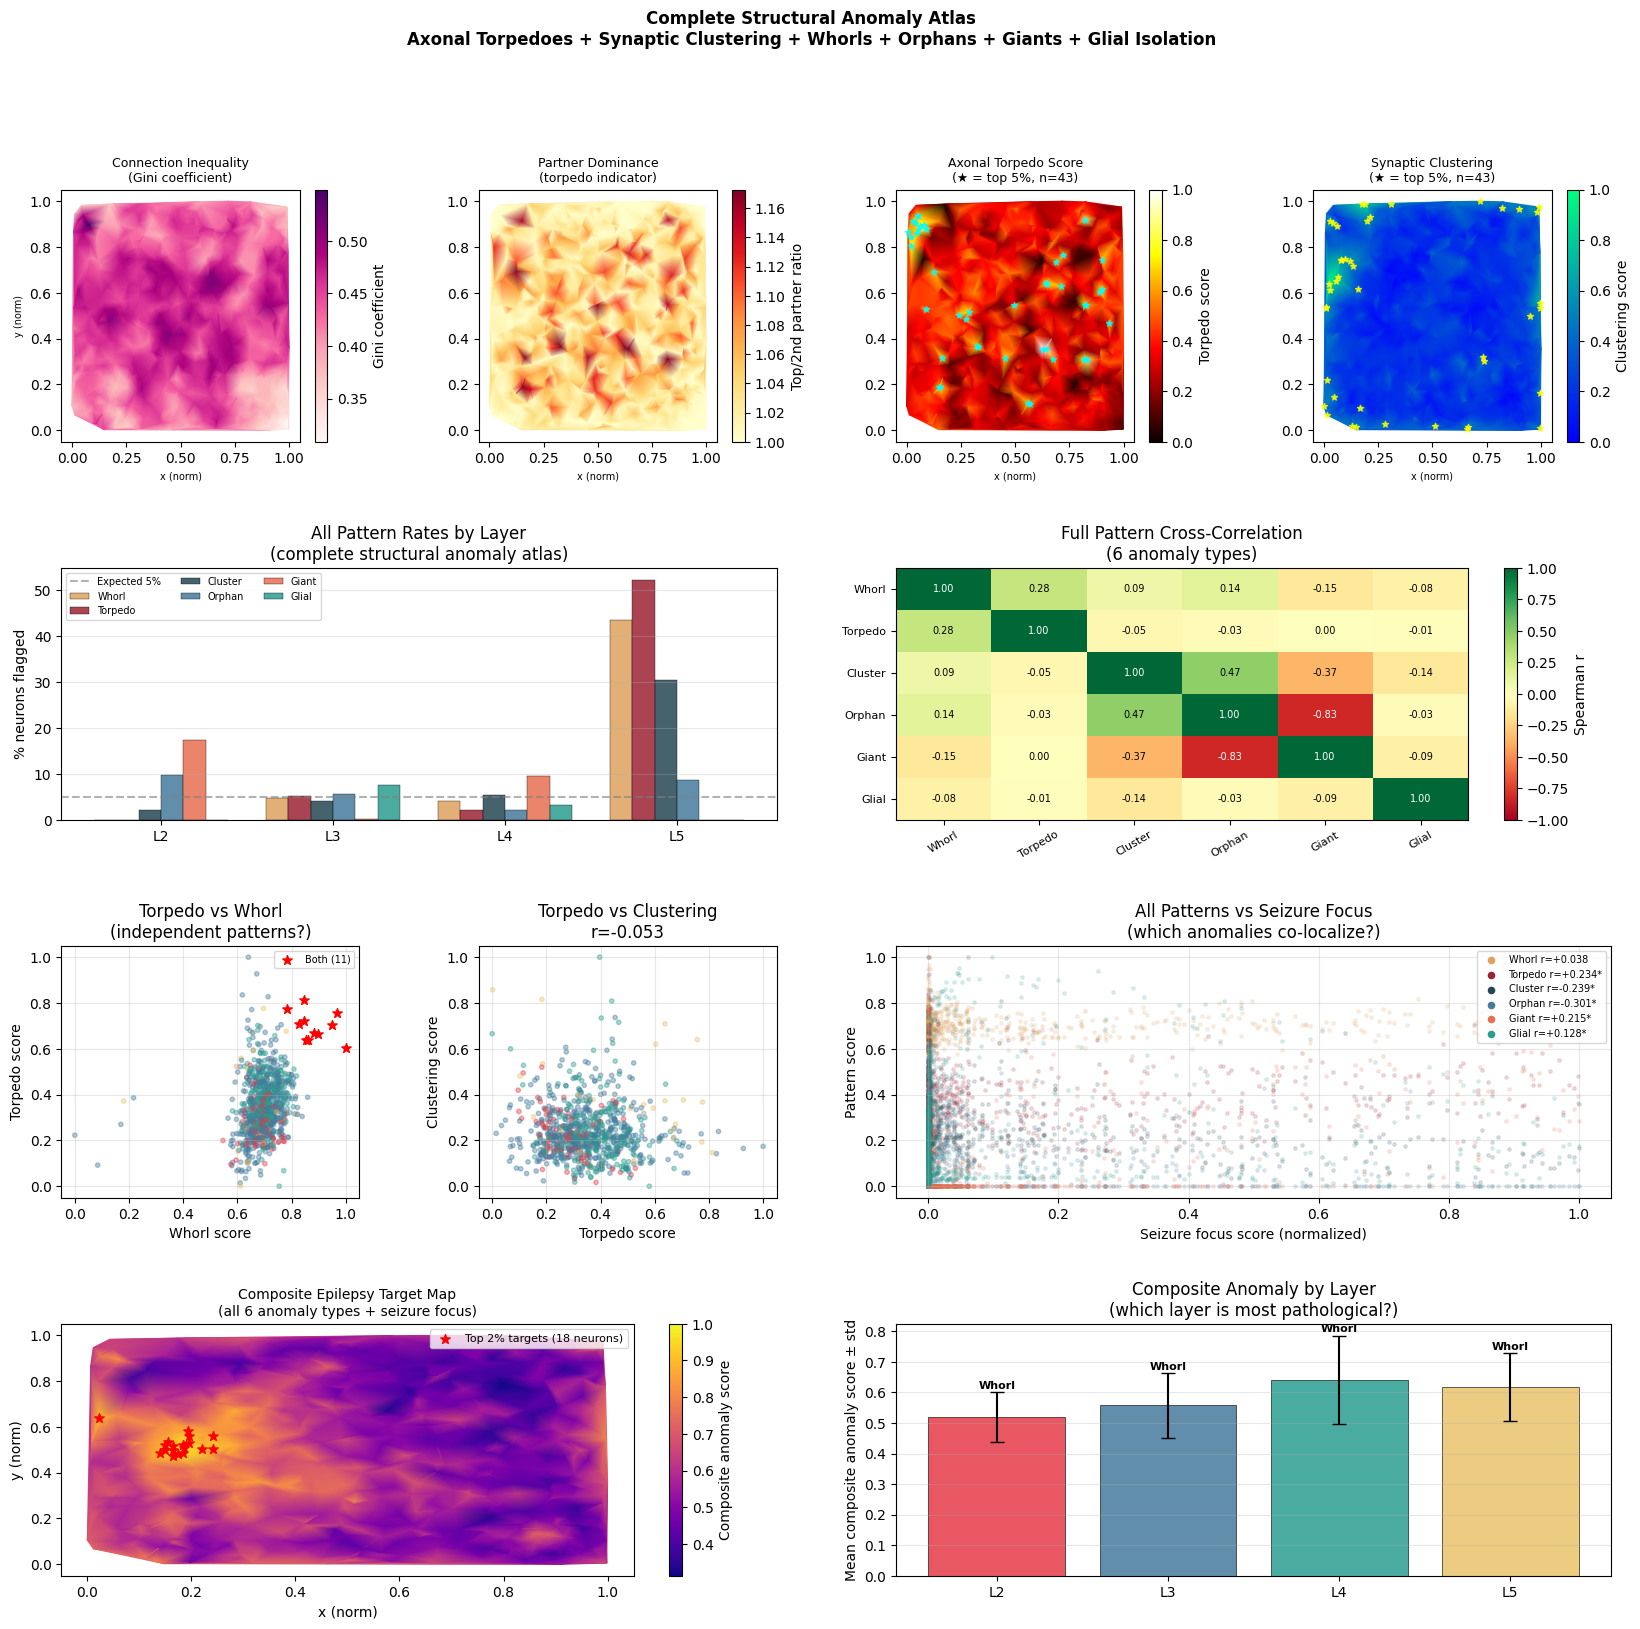

Saved: anomaly_atlas.png

Top 2% composite targets: 18 neurons
Layer distribution of top targets:
  Layer 2: 0 neurons
  Layer 3: 0 neurons
  Layer 4: 18 neurons
  Layer 5: 0 neurons


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# FULL STRUCTURAL ANOMALY ATLAS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.tri import Triangulation
from matplotlib.lines import Line2D
import numpy as np

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(4, 4, figure=fig,
                         hspace=0.50, wspace=0.40)

layer_colors_map = {
    'Layer 1':'#F4A261','Layer 2':'#E63946',
    'Layer 3':'#457B9D','Layer 4':'#2A9D8F',
    'Layer 5':'#E9C46A','White matter':'#6D6875',
    'unclassified':'#999999'
}
node_colors = [layer_colors_map.get(l,'#999')
               for l in layer_labels]
triang = Triangulation(coords_norm[:,0],
                        coords_norm[:,1], triangles)

# ── Row 1: Novel pattern spatial maps ────────────────────────
# Plot 1: Gini coefficient spatial map
ax1 = fig.add_subplot(gs[0, 0])
sc1 = ax1.tripcolor(triang, gini_scores,
                    cmap='RdPu', shading='gouraud')
plt.colorbar(sc1, ax=ax1, label='Gini coefficient')
ax1.set_title('Connection Inequality\n(Gini coefficient)',
              fontsize=9)
ax1.set_xlabel('x (norm)', fontsize=7)
ax1.set_ylabel('y (norm)', fontsize=7)

# Plot 2: Dominance ratio spatial map
ax2 = fig.add_subplot(gs[0, 1])
dom_plot = np.clip(dominance_ratio, 0,
                   np.percentile(dominance_ratio, 99))
sc2 = ax2.tripcolor(triang, dom_plot,
                    cmap='YlOrRd', shading='gouraud')
plt.colorbar(sc2, ax=ax2, label='Top/2nd partner ratio')
ax2.set_title('Partner Dominance\n(torpedo indicator)',
              fontsize=9)
ax2.set_xlabel('x (norm)', fontsize=7)

# Plot 3: Torpedo score spatial map
ax3 = fig.add_subplot(gs[0, 2])
sc3 = ax3.tripcolor(triang, torpedo_norm,
                    cmap='hot', shading='gouraud')
plt.colorbar(sc3, ax=ax3, label='Torpedo score')
ax3.scatter(coords_norm[torpedo_candidates, 0],
            coords_norm[torpedo_candidates, 1],
            c='cyan', s=20, marker='*', zorder=5,
            alpha=0.8)
ax3.set_title(f'Axonal Torpedo Score\n'
              f'(★ = top 5%, n={len(torpedo_candidates)})',
              fontsize=9)
ax3.set_xlabel('x (norm)', fontsize=7)

# Plot 4: Synaptic clustering score spatial map
ax4 = fig.add_subplot(gs[0, 3])
sc4 = ax4.tripcolor(triang, cluster_norm,
                    cmap='winter', shading='gouraud')
plt.colorbar(sc4, ax=ax4, label='Clustering score')
ax4.scatter(coords_norm[cluster_candidates, 0],
            coords_norm[cluster_candidates, 1],
            c='yellow', s=20, marker='*', zorder=5,
            alpha=0.8)
ax4.set_title(f'Synaptic Clustering\n'
              f'(★ = top 5%, n={len(cluster_candidates)})',
              fontsize=9)
ax4.set_xlabel('x (norm)', fontsize=7)

# ── Row 2: Pattern rate by layer ──────────────────────────────
ax5 = fig.add_subplot(gs[1, :2])
layers_plot = ['Layer 2','Layer 3','Layer 4','Layer 5']
pattern_data = {
    'Whorl':    (whorl_score_norm,  '#DDA15E'),
    'Torpedo':  (torpedo_norm,      '#9B2335'),
    'Cluster':  (cluster_norm,      '#264653'),
    'Orphan':   (orphan_norm,       '#457B9D'),
    'Giant':    (giant_norm,        '#E76F51'),
    'Glial':    (glial_norm,        '#2A9D8F'),
}
x_pos = np.arange(len(layers_plot))
width = 0.13
for ki, (pname, (pdata, pcolor)) in enumerate(
        pattern_data.items()):
    thresh = np.percentile(pdata, 95)
    rates  = []
    for l in layers_plot:
        lmask = layer_labels == l
        if lmask.sum() == 0:
            rates.append(0)
            continue
        rates.append(
            (pdata[lmask] >= thresh).sum() /
            lmask.sum() * 100)
    offset = (ki - 2.5) * width
    ax5.bar(x_pos + offset, rates, width,
            label=pname, color=pcolor,
            alpha=0.85, edgecolor='black',
            linewidth=0.3)
ax5.axhline(y=5.0, color='gray', linestyle='--',
            alpha=0.6, label='Expected 5%')
ax5.set_xticks(x_pos)
ax5.set_xticklabels([l.replace('Layer ','L')
                      for l in layers_plot])
ax5.set_ylabel('% neurons flagged')
ax5.set_title('All Pattern Rates by Layer\n'
              '(complete structural anomaly atlas)')
ax5.legend(fontsize=7, ncol=3)
ax5.grid(alpha=0.3, axis='y')

# ── Plot 6: Full 6x6 correlation matrix ──────────────────────
ax6 = fig.add_subplot(gs[1, 2:])
all_patterns = np.column_stack([
    whorl_score_norm, torpedo_norm, cluster_norm,
    orphan_norm, giant_norm, glial_norm
])
pattern_names = ['Whorl','Torpedo','Cluster',
                 'Orphan','Giant','Glial']
corr_full = np.zeros((6, 6))
for i in range(6):
    for j in range(6):
        r, _ = spearmanr(all_patterns[:,i],
                          all_patterns[:,j])
        corr_full[i, j] = r

im6 = ax6.imshow(corr_full, cmap='RdYlGn',
                  vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im6, ax=ax6, label='Spearman r')
ax6.set_xticks(range(6))
ax6.set_yticks(range(6))
ax6.set_xticklabels(pattern_names, fontsize=8,
                     rotation=30)
ax6.set_yticklabels(pattern_names, fontsize=8)
ax6.set_title('Full Pattern Cross-Correlation\n'
              '(6 anomaly types)')
for i in range(6):
    for j in range(6):
        ax6.text(j, i, f'{corr_full[i,j]:.2f}',
                 ha='center', va='center',
                 fontsize=7,
                 color='black'
                 if abs(corr_full[i,j]) < 0.6
                 else 'white')

# ── Row 3: Scatter plots ──────────────────────────────────────
# Plot 7: Torpedo vs Whorl
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(whorl_score_norm, torpedo_norm,
            c=node_colors, alpha=0.4, s=10)
overlap_tw = torpedo_set & whorl_set
if overlap_tw:
    idx = list(overlap_tw)
    ax7.scatter(whorl_score_norm[idx],
                torpedo_norm[idx],
                c='red', s=50, marker='*',
                zorder=5,
                label=f'Both ({len(overlap_tw)})')
ax7.set_xlabel('Whorl score')
ax7.set_ylabel('Torpedo score')
ax7.set_title('Torpedo vs Whorl\n(independent patterns?)')
ax7.legend(fontsize=7); ax7.grid(alpha=0.3)

# Plot 8: Cluster vs Torpedo
ax8 = fig.add_subplot(gs[2, 1])
ax8.scatter(torpedo_norm, cluster_norm,
            c=node_colors, alpha=0.4, s=10)
ax8.set_xlabel('Torpedo score')
ax8.set_ylabel('Clustering score')
r_tc, _ = spearmanr(torpedo_norm, cluster_norm)
ax8.set_title(f'Torpedo vs Clustering\nr={r_tc:.3f}')
ax8.grid(alpha=0.3)

# Plot 9: All patterns vs seizure focus
ax9 = fig.add_subplot(gs[2, 2:])
seizure_n = seizure_combined / seizure_combined.max()
for pname, (pdata, pcolor) in pattern_data.items():
    r, p = spearmanr(pdata, seizure_n)
    ax9.scatter([], [], c=pcolor, s=20,
                label=f'{pname} r={r:+.3f}'
                      f'{"*" if p<0.05 else ""}')
# Plot all
for pname, (pdata, pcolor) in pattern_data.items():
    ax9.scatter(seizure_n, pdata,
                c=pcolor, alpha=0.15, s=6)
ax9.set_xlabel('Seizure focus score (normalized)')
ax9.set_ylabel('Pattern score')
ax9.set_title('All Patterns vs Seizure Focus\n'
              '(which anomalies co-localize?)')
ax9.legend(fontsize=7, loc='upper right')
ax9.grid(alpha=0.3)

# ── Row 4: Complete epilepsy target map ──────────────────────
ax10 = fig.add_subplot(gs[3, :2])
# Create composite score: all 6 patterns + seizure
composite = np.column_stack([
    whorl_score_norm, torpedo_norm, cluster_norm,
    orphan_norm, giant_norm, glial_norm,
    seizure_n
]).mean(axis=1)
composite /= composite.max()

sc10 = ax10.tripcolor(triang, composite,
                      cmap='plasma', shading='gouraud')
plt.colorbar(sc10, ax=ax10,
             label='Composite anomaly score')
# Mark top 2% as highest priority targets
top2pct = np.where(
    composite >= np.percentile(composite, 98))[0]
ax10.scatter(coords_norm[top2pct, 0],
             coords_norm[top2pct, 1],
             c='red', s=50, marker='*',
             zorder=6,
             label=f'Top 2% targets '
                   f'({len(top2pct)} neurons)')
ax10.set_title('Composite Epilepsy Target Map\n'
               '(all 6 anomaly types + seizure focus)',
               fontsize=10)
ax10.set_xlabel('x (norm)')
ax10.set_ylabel('y (norm)')
ax10.legend(fontsize=8)

# ── Plot 11: Layer profile of composite score ─────────────────
ax11 = fig.add_subplot(gs[3, 2:])
layer_order = ['Layer 2','Layer 3','Layer 4','Layer 5']
comp_means = []
comp_stds  = []
for l in layer_order:
    lmask = layer_labels == l
    vals  = composite[lmask]
    comp_means.append(vals.mean())
    comp_stds.append(vals.std())

bar_colors = [layer_colors_map.get(l,'#999')
               for l in layer_order]
ax11.bar([l.replace('Layer ','L') for l in layer_order],
         comp_means, yerr=comp_stds, capsize=5,
         color=bar_colors, alpha=0.85,
         edgecolor='black', linewidth=0.5)
ax11.set_ylabel('Mean composite anomaly score ± std')
ax11.set_title('Composite Anomaly by Layer\n'
               '(which layer is most pathological?)')
ax11.grid(alpha=0.3, axis='y')

# Annotate with dominant pattern per layer
dominant_patterns = {}
for l in layer_order:
    lmask = layer_labels == l
    if lmask.sum() == 0:
        continue
    pattern_means = {
        pname: pdata[lmask].mean()
        for pname, (pdata, _) in pattern_data.items()
    }
    dominant_patterns[l] = max(pattern_means,
                                key=pattern_means.get)

for i, l in enumerate(layer_order):
    dom = dominant_patterns.get(l, '?')
    ax11.text(i, comp_means[i] + comp_stds[i] + 0.005,
              dom, ha='center', va='bottom',
              fontsize=8, fontweight='bold')

plt.suptitle('Complete Structural Anomaly Atlas\n'
             'Axonal Torpedoes + Synaptic Clustering + '
             'Whorls + Orphans + Giants + Glial Isolation',
             fontsize=12, fontweight='bold')
plt.savefig('anomaly_atlas.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Saved: anomaly_atlas.png")
print(f"\nTop 2% composite targets: {len(top2pct)} neurons")
print(f"Layer distribution of top targets:")
for l in layer_order:
    lmask = layer_labels == l
    n_top = ((composite >= np.percentile(
        composite, 98)) & lmask).sum()
    print(f"  {l}: {n_top} neurons")

**Checkpoint:** run the cell below after finishing this notebook so `08_Seizure_Propagation_PDE` can restore this state.

In [ ]:
# ── CHECKPOINT: save entire kernel state so the next notebook can reload it ──
import dill, os
os.makedirs("checkpoints", exist_ok=True)
dill.dump_session("checkpoints/07_state.pkl")
print("Saved checkpoint: checkpoints/07_state.pkl")